# Combined Global / Local fit for pointing recovery

In [1]:
import astropy.units as u
import jax.numpy as jnp
import numpy as np
from astropy.coordinates import EarthLocation, SkyCoord
from astropy.time import Time

from nyx.atmosphere import single_scattering
from nyx.core import Optimizer, Scene, freeze_all, unfreeze
from nyx.core.geometry import Geometry
from nyx.core.observation import Observation
from nyx.emitter import Airglow, Moon, Stars, ZodiacalLight
from nyx.instrument import EffectiveApertureInstrument

E0604 12:45:30.923960 1342719 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0604 12:45:30.924077 1342720 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0604 12:45:30.924136 1342721 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]


## Building model:

In [2]:
geo = Geometry(
    wvls=jnp.linspace(300, 700, 40) * u.nm,  # wavelength grid
    nside=32,  # HEALPix resolution
    ngrid=2,  # FOV eval grid
    fov=3.5 * u.deg,  # field of view
)

hess_ct1 = EffectiveApertureInstrument.load("../../nyx/data/HESS_CT1.h5", geo, batch_size=64)

atmosphere = single_scattering.HGOzoneAbsorption(geo)

sources = {
    "airglow": Airglow.from_eso_skycalc(geo, sfu=100.0),
    "zodiacal": ZodiacalLight.from_leinert1998(geo),
    "GaiaDR3": Stars.from_gaia_dr3(geo, lim_mag=12),
    "moon": Moon.from_jones2013(geo),
}

## Creating an example observation:

In [3]:
location = EarthLocation.from_geodetic(
    lon=16.5028 * u.deg,
    lat=-23.2728 * u.deg,
    height=1.8 * u.km,
)
times = Time("2021-06-12T02:12:16", scale="utc") + jnp.linspace(0, 30, 120) * 60 * u.s
target = SkyCoord(l=0 * u.deg, b=0 * u.deg, frame="galactic")

obs = Observation(location, times, target, geo)

## Creating target images:

In [4]:
scene = Scene.build(hess_ct1, atmosphere, sources, obs)

# Add random pointing offsets:
nshift = np.deg2rad(np.random.uniform(-0.05, 0.05, size=(scene.nobs["instrument"], 2)))
scene = scene.set("instrument.shift", jnp.array(nshift))

# Add a dimished efficiency:
scene = scene.set("instrument.efficiency", jnp.array([0.7]))

# Add a random flatfielding offset:
pix_efficiency_shift = np.random.lognormal(
    mean=0, sigma=0.1, size=scene.instrument.pixel_efficiency.value.shape
)
scene = scene.set("instrument.pixel_efficiency", jnp.array(pix_efficiency_shift))

In [5]:
rates = scene.render()["instrument"]

rel_error = 0.05  # 5% relative error seems realistic from HMC of flatfielded data
N = 1 / (2 * rel_error**2)
truth_images = rates * np.sqrt(np.random.chisquare(df=N, size=rates.shape) / N)

## Initializing clean scene again:

In [6]:
sources = {
    "airglow": Airglow.from_eso_skycalc(geo, sfu=100.0),
    "zodiacal": ZodiacalLight.from_leinert1998(geo),
    "GaiaDR3": Stars.from_gaia_dr3(geo, lim_mag=12),
    "moon": Moon.from_jones2013(geo),
}

scene = Scene.build(hess_ct1, atmosphere, sources, obs)

In [7]:
from nyx.utils.profiler import profile_render

profile_render(scene)


  Render memory profile (backend=gpu, device=cuda:0)
  Memory before render: 193.6 MB
  Memory after render:  194.2 MB
  Peak memory:          2400.5 MB
  Render overhead:      0.5 MB
  Result shape:         (120, 960)
  Output[instrument]:            (120, 960)  float32  0.44 MB

  Device memory (cuda:0):
    In use:     194.2 MB
    Peak:      2400.5 MB
    Limit:    36407.8 MB
    Free:     36213.6 MB



{'before_mb': 193.61376953125,
 'after_mb': 194.153076171875,
 'peak_mb': 2400.48779296875,
 'render_mb': 0.539306640625,
 'result_shape': (120, 960)}

## Creating a loss function:

We first prefit using all instrument parameters unfrozen:

In [8]:
%%time
import optimistix as optx

scene = freeze_all(scene)
scene = unfreeze(scene, lambda s: s.instruments["instrument"].shift)
scene = unfreeze(scene, lambda s: s.instruments["instrument"].rotation)
scene = unfreeze(scene, lambda s: s.instruments["instrument"].efficiency)


def residuals_fn(scene):
    preds = scene.render()["instrument"]
    return (preds - truth_images) / (truth_images * rel_error)


opt = Optimizer(residuals_fn, optx.LBFGS(rtol=1e-6, atol=1e-6))
fitted, sol = opt.run(scene, max_steps=1024)

CPU times: user 26.6 s, sys: 1.35 s, total: 28 s
Wall time: 28.1 s


In [9]:
print(
    jnp.sum(residuals_fn(fitted) ** 2) / scene.nobs["instrument"],
    sol.result,
    int(sol.stats["num_steps"]),
)

4616.4937 optimistix._solution.RESULTS<> 92


Calculating the errors on our fitted parameters:

In [10]:
%%time
errors = opt.errors(fitted, batch_size=64)

/home/atuin/b129dc/b129dc13/environments/conda/envs/iactools_gpu/lib/python3.12/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


CPU times: user 1min 55s, sys: 1.04 s, total: 1min 56s
Wall time: 2min


We can see that we get decent results, with the standard deviation being around relatively low

Text(0, 0.5, '$\\Delta$y [arcsec]')

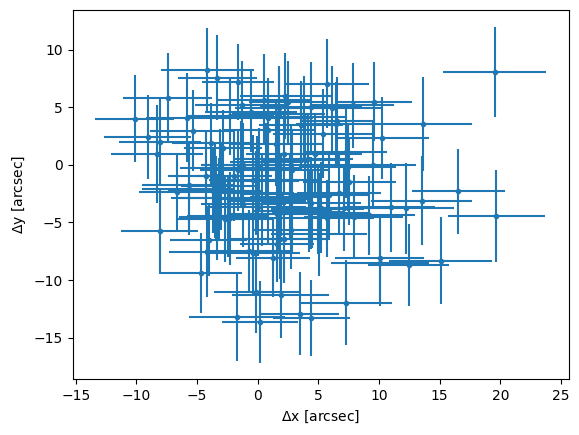

In [11]:
import matplotlib.pyplot as plt

dxdy = np.rad2deg(fitted.instrument.shift.value - nshift) * 3600

dx_err = np.rad2deg(errors.instrument.shift.value[:, 0]) * 3600
dy_err = np.rad2deg(errors.instrument.shift.value[:, 1]) * 3600
plt.errorbar(dxdy[:, 0], dxdy[:, 1], yerr=dy_err, xerr=dx_err, fmt=".")
plt.xlabel(r"$\Delta$x [arcsec]")
plt.ylabel(r"$\Delta$y [arcsec]")

The effect of the flatfielding (and us ignoring it in the fitting) leads to our error estimates not having the correct coverage! This shows how important it is to either include the pixel efficiencies in the fit or to have a good flatfielding estimate otherwise.

In [12]:
normed = np.concatenate([dxdy[:, 0] / dx_err, dxdy[:, 1] / dy_err])

within_1sig = np.mean(np.abs(normed) < 1)  # expect ~68%
within_2sig = np.mean(np.abs(normed) < 2)  # expect ~95%
print(f"1σ: {within_1sig:.0%}, 2σ: {within_2sig:.0%}")

1σ: 47%, 2σ: 81%


In [13]:
fitted.parameters_table()

name,value,scale,shape,per_obs,frozen
airglow.spectral_model.params,+1.0000e+02,1.00e+02,(),-,yes
atmosphere.Mie.angstrom_exp,+1.5000e+00,1.00e+00,(),-,yes
atmosphere.Mie.aod_500,+1.0000e-01,5.00e-01,(),-,yes
atmosphere.Mie.hg_asymmetry,+7.5000e-01,5.00e-01,(),-,yes
instrument.efficiency,+6.8808e-01,1.00e+00,(),-,-
instrument.pixel_efficiency,+1.0000e+00,1.00e+00,"(960,)",-,yes
instrument.rotation,"[-1.8765e-03, +1.0095e-03]",1.00e-02,"(120, 1)",yes,-
instrument.shift,"[-8.8758e-04, +8.6884e-04]",1.00e-03,"(120, 2)",yes,-
